In [202]:
import get_ps_21cmEMU
import numpy as np
from getdist import MCSamples, plots
import torch
_ = torch.manual_seed(0)
import matplotlib.pyplot as plt
# plt.style.use('sty.mplstyle')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [203]:
# calling the emulator and getting the 1D power spectrum training data set

redshift_value = 8.01
# fiducial parameters for the emulator
log_f_star10 = -1.2
alpha_star = 0.5
t_star = 0.55
log_f_esc10 = -1.3
alpha_esc = 0
log_f_star7_mini = -2.5
log_f_esc7_mini = -1.5
log_l_x = 40.0
log_l_x_mini = 41.5
nu_x_thresh = 500
sigma_8 = 0.8118


astro_params = {"F_STAR10": log_f_star10, 
          'ALPHA_STAR': alpha_star,
          't_STAR': t_star,
          'F_ESC10': log_f_esc10,
          'ALPHA_ESC': alpha_esc,
          'F_STAR7_MINI': log_f_star7_mini,
          'F_ESC7_MINI': log_f_esc7_mini,
          'L_X': log_l_x,
          'L_X_MINI': log_l_x_mini,
          'NU_X_THRESH': nu_x_thresh,
          'SIGMA_8': sigma_8
         }

ps_1_d = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value)
# noise_sigma = np.load("data/sigma_pk_z8.01_108_hours.npy")
noise_sigma = np.load("data/sigma_pk_z8.01.npy")



def get_traning_data(theta, num_simulations):
    " five parameters: F_STAR10, F_ESC10, ALPHA_STAR"

    if torch.is_tensor(theta):
        theta = theta.detach().cpu().numpy()
    arr_f_star_10 = theta[:, 0]
    arr_f_esc_10 = theta[:, 1]
    arr_alpha_star = theta[:, 2]
    arr_t_star = theta[:, 3]
    arr_NU_X_THRESH = theta[:, 4]


    # print(f_star_10, f_esc_10, alpha_star)

    ps_data = np.zeros((num_simulations, 32))

    for i in range(num_simulations):
        astro_params = {"F_STAR10": arr_f_star_10[i], 
          'ALPHA_STAR': arr_alpha_star[i],
          't_STAR': arr_t_star[i],
          'F_ESC10': arr_f_esc_10[i],
          'ALPHA_ESC': alpha_esc,
          'F_STAR7_MINI': log_f_star7_mini,
          'F_ESC7_MINI': log_f_esc7_mini,
          'L_X': log_l_x,
          'L_X_MINI': log_l_x_mini,
          'NU_X_THRESH': arr_NU_X_THRESH[i],
          'SIGMA_8': sigma_8
         }
        ps = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value)
        # noise_sigma = 0.05 * ps # 5% noise level
        # noise_sigma = 0.2 * ps # 5% noise level

        np.random.seed(i)  # for reproducibility
        ps_noisy = ps + np.random.normal(0, noise_sigma, size=ps.shape) # add noise to the power spectrum
        ps_data[i, :] = ps_noisy
        
    return ps_data

In [204]:
# defining the parameter space for training data generation
from sbi.utils import BoxUniform
# lower_bounds = np.array([-2.0, -3.0, 0.0])  # lower bounds for F_STAR10, F_ESC10, ALPHA_STAR
# upper_bounds = np.array([-0.5, 0.0, 1.0])  # upper bounds for F_STAR10, F_ESC10, ALPHA_STAR
# prior = BoxUniform(low=torch.tensor(lower_bounds), high=torch.tensor(upper_bounds), device=device)
lower_bounds = np.array([-2.0, -3.0, 0.0,0.01,100])  # lower bounds for F_STAR10, F_ESC10, ALPHA_STAR, t_STAR, NU_X_THRESH
upper_bounds = np.array([-0.5, 0.0, 1.0,1,1500 ])  # upper bounds for F_STAR10, F_ESC10, ALPHA_STAR, t_STAR, NU_X_THRESH
prior = BoxUniform(low=torch.tensor(lower_bounds), high=torch.tensor(upper_bounds), device=device)


In [279]:
# choosing the sbi method for inference: NPE
# from sbi.inference import NPE
# inference = NPE(prior=prior, device=device)


# from sbi.neural_nets import posterior_nn
# from sbi.inference import NPE
# density_estimator_build_fun = posterior_nn(
#     model="maf", hidden_features=50, num_transforms=12
# )
# inference = NPE(prior=prior, density_estimator=density_estimator_build_fun, device=device)

from sbi.neural_nets import posterior_nn
from sbi.inference import NPE
density_estimator_build_fun = posterior_nn(
    model="nsf", hidden_features=50, num_transforms=12
)

inference = NPE(prior=prior, density_estimator=density_estimator_build_fun, device=device)

# MDN inmplementation
# from sbi.neural_nets import posterior_nn
# from sbi.inference import NPE
# density_estimator_build_fun = posterior_nn(
#     model="mdn", 
#     hidden_features=32, 
#     num_components=3, 
#     num_blocks=6
# )
# inference = NPE(prior=prior, density_estimator=density_estimator_build_fun, device=device)

In [302]:
# creating the training data set
# num_simulations = 10000
# theta = prior.sample((num_simulations,))
# x = get_traning_data(theta, num_simulations)
# x_torch = torch.tensor(x, dtype=torch.float32)
# theta = np.load('data/theta_training_data_f_star10_f_esc10_alpha_star_ska_1080_num_simulations_30000.npy')
# x = np.load('data/ps_training_data_f_star10_f_esc10_alpha_star_ska_1080_num_simulations_30000.npy')
theta = np.load('data/theta_training_data_f_star10_f_esc10_alpha_star_t_star_nu_x_thresh_ska_1080_num_simulations_30000.npy')
x = np.load('data/ps_training_data_f_star10_f_esc10_alpha_star_t_star_nu_x_thresh_ska_1080_num_simulations_30000.npy')
# x_mean = np.mean(x, axis=0)
# x_std = np.std(x, axis=0)
x_standardized = (x - x.mean(axis=0)) / (x.std(axis=0) + 1e-8)

# x_torch = torch.tensor(x, dtype=torch.float32, device=device)
x_torch = torch.tensor(x_standardized, dtype=torch.float32, device=device)
theta_torch = torch.tensor(theta, dtype=torch.float32, device=device)

In [281]:
# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/ps_training_data_f_star10_f_esc10_alpha_star.npy', x)
# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/theta_training_data_f_star10_f_esc10_alpha_star.npy', theta)

# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/ps_training_data_f_star10_f_esc10_alpha_star_10_per_error.npy', x)
# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/theta_training_data_f_star10_f_esc10_alpha_star_10_per_error.npy', theta)

In [282]:
# np.save('data/ps_training_data_f_star10_f_esc10_alpha_star_ska_108_num_simulations_10000.npy', x)
# np.save('data/theta_training_data_f_star10_f_esc10_alpha_star_ska_108_num_simulations_10000.npy', theta)
# np.save('data/ps_training_data_f_star10_f_esc10_alpha_star_ska_1080_num_simulations_10000.npy', x)
# np.save('data/theta_training_data_f_star10_f_esc10_alpha_star_ska_1080_num_simulations_10000.npy', theta.cpu().numpy())

In [303]:
# training the density estimator with the training data set
inference = inference.append_simulations(theta_torch, x_torch)
density_estimator = inference.train()

/home/leon/anaconda3/lib/python3.13/site-packages/sbi/inference/trainers/npe/npe_base.py:184: UserWarning: Data x has device 'cuda:0'. Moving x to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(
/home/leon/anaconda3/lib/python3.13/site-packages/sbi/inference/trainers/npe/npe_base.py:184: UserWarning: Parameters theta has device 'cuda:0'. Moving theta to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(


ValueError: This neural network has already been trained. If you want to continue training without adding new simulations, set resume_training=True. If you appended new simulations, you must either provide a proposal in append_simulations(), or set force_first_round_loss=True for simulations drawn from the prior. Warning: Setting force_first_round_loss=True with simulations not drawn from the prior will produce the proposal posterior instead of the true posterior, which is typically more narrow.

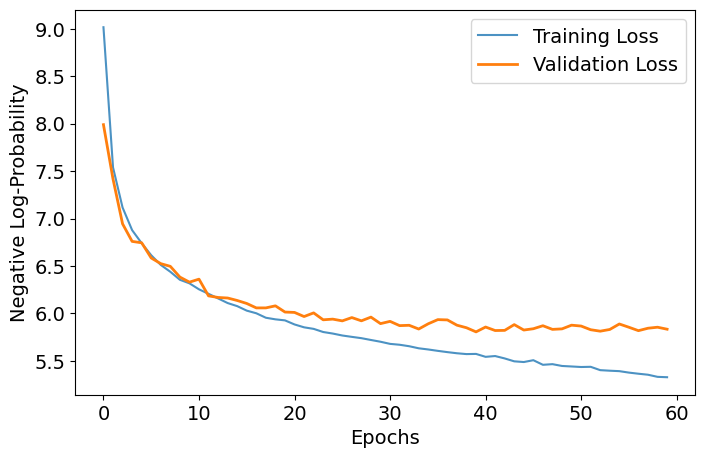

In [304]:
train_loss = inference.summary["training_loss"]
val_loss = inference.summary["validation_loss"]

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Training Loss", alpha=0.8)
plt.plot(val_loss, label="Validation Loss", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Negative Log-Probability")
plt.legend()
# plt.grid(True)
plt.show()

In [305]:
posterior = inference.build_posterior()
print(posterior)


Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


In [306]:
# import pickle
# with open("trained_models/npe_five_params_nsf_hidden_features_50_num_transforms_12.pkl", "wb") as handle:
#     pickle.dump(posterior, handle)

In [307]:
ps_obs = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value) # test data for inference
ps_obs_standardized = (ps_obs - x.mean(axis=0)) / (x.std(axis=0) + 1e-8)
# ps_obs_torch = torch.tensor(ps_obs, dtype=torch.float32, device=device)
ps_obs_torch = torch.tensor(ps_obs_standardized, dtype=torch.float32, device=device)

In [308]:
posterior_samples = posterior.sample((1000,), x=ps_obs_torch) # draw 1000 posterior samples

  0%|          | 0/1000 [00:00<?, ?it/s]

Removed no burn in


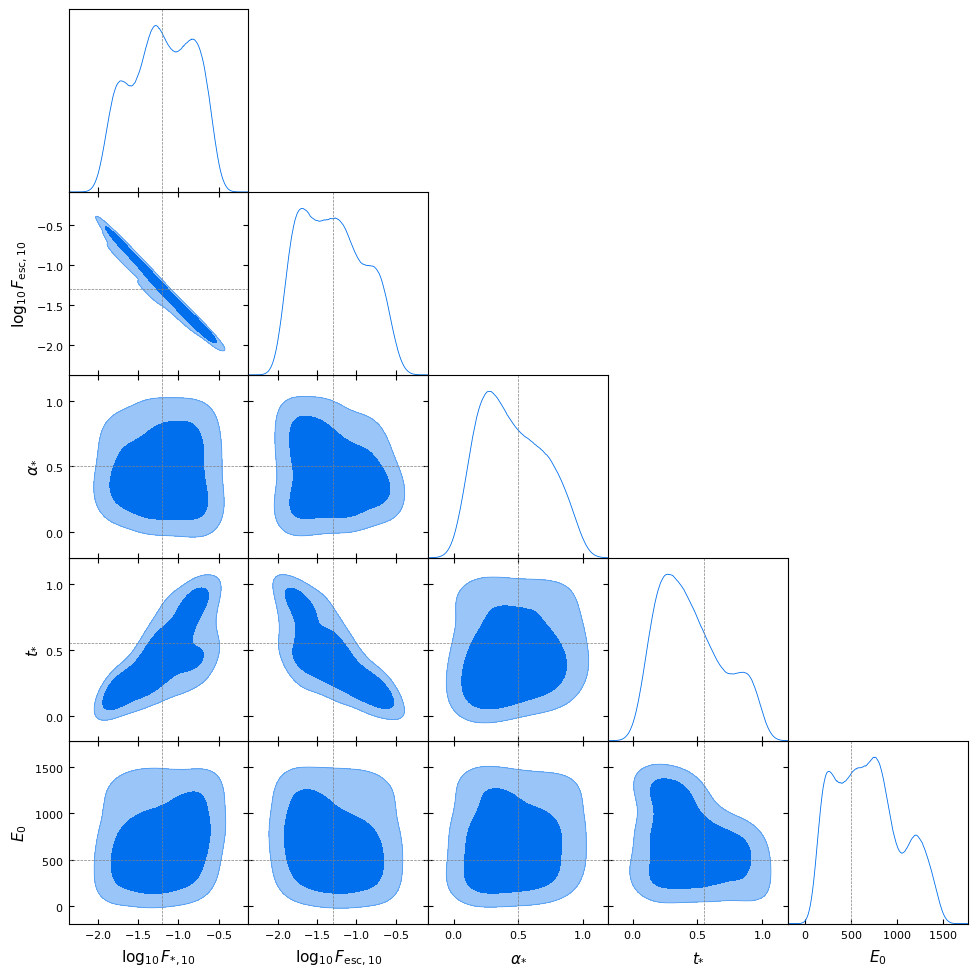

In [309]:
labels = [r'\log_{10} F_{*,10}', r'\log_{10} F_{\rm esc,10}', r'\alpha_{*}', r't_{*}', r'E_0']
names = ['F_STAR10', 'F_ESC10', 'ALPHA_STAR', 't_STAR', 'E_0']
true_params = [log_f_star10, log_f_esc10, alpha_star, t_star, nu_x_thresh]

samples = MCSamples(
    samples=posterior_samples.cpu().numpy(), 
    names=names,
    labels=labels
)

# dictionary mapping the parameter names to their true values
markers_dict = {name: val for name, val in zip(names, true_params)}

g = plots.get_subplot_plotter()
g.triangle_plot(samples, filled=True, markers=markers_dict)

In [310]:
f_star_100_samples = theta_torch[:100, 0].cpu().numpy() 
f_esc_100_samples = theta_torch[:100, 1].cpu().numpy()  
alpha_star_samples = theta_torch[:100, 2].cpu().numpy() 
t_star_samples = theta_torch[:100, 3].cpu().numpy()
nu_x_thresh_samples = theta_torch[:100, 4].cpu().numpy()

### Posterior Predictive Checks

In [311]:
theta_posterior_ppc = posterior.sample((200,), x=ps_obs_torch) # draw 1000 posterior samples for posterior predictive check
x_predictive = get_traning_data(theta_posterior_ppc, 200) # generate predictive data from the posterior samples
x_predictive_standardized = (x_predictive - x.mean(axis=0)) / (x.std(axis=0) + 1e-8)

  0%|          | 0/200 [00:00<?, ?it/s]

In [312]:
# x_predictive = torch.tensor(x_predictive, dtype=torch.float32)
x_predictive = torch.tensor(x_predictive_standardized, dtype=torch.float32)

In [313]:
x_predictive_mean = torch.mean(x_predictive, axis=0)
print("Posterior predictives: ", x_predictive_mean)

Posterior predictives:  tensor([0.2263, 0.2685, 0.2591, 0.2495, 0.4151, 0.4599, 0.5269, 0.6766, 0.7843,
        0.9766, 1.1642, 1.2878, 1.4464, 1.6186, 1.7422, 1.8422, 1.9441, 2.0005,
        1.9839, 1.9626, 1.8281, 1.7376, 1.6050, 1.4440, 1.2138, 1.0671, 0.9514,
        0.8180, 0.7316, 0.6090, 0.4812, 0.4695])


In [314]:
print("Posterior predictives: ", torch.mean(x_predictive, axis=0))
print("Observation: ", ps_obs_torch)

Posterior predictives:  tensor([0.2263, 0.2685, 0.2591, 0.2495, 0.4151, 0.4599, 0.5269, 0.6766, 0.7843,
        0.9766, 1.1642, 1.2878, 1.4464, 1.6186, 1.7422, 1.8422, 1.9441, 2.0005,
        1.9839, 1.9626, 1.8281, 1.7376, 1.6050, 1.4440, 1.2138, 1.0671, 0.9514,
        0.8180, 0.7316, 0.6090, 0.4812, 0.4695])
Observation:  tensor([0.1768, 0.2021, 0.2461, 0.3012, 0.3743, 0.4534, 0.5619, 0.6843, 0.8295,
        0.9948, 1.1769, 1.3299, 1.4940, 1.6591, 1.7786, 1.8984, 1.9646, 1.9922,
        1.9938, 1.9389, 1.8650, 1.7338, 1.5794, 1.4180, 1.2334, 1.0892, 0.9509,
        0.8250, 0.7288, 0.6270, 0.5547, 0.5008], device='cuda:0')


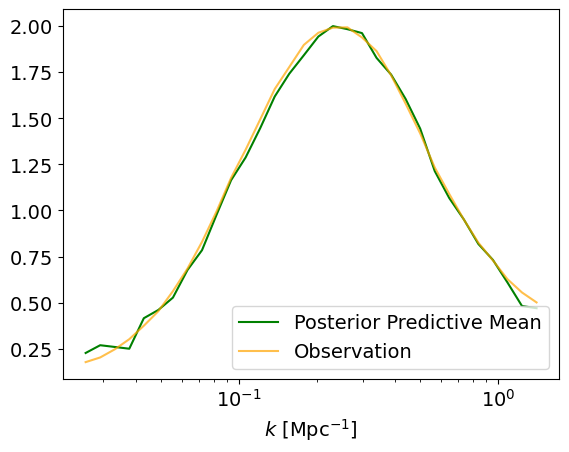

In [315]:
k_values = np.load('data/k_values.npy')
plt.plot(k_values, torch.mean(x_predictive, axis=0), label='Posterior Predictive Mean', color='green')
# plt.errorbar(k_values, torch.mean(x_predictive, axis=0), yerr=torch.std(x_predictive, axis=0), color='green', alpha=0.5, label='Posterior Predictive Std Dev')
plt.plot(k_values, ps_obs_torch.cpu(), label='Observation', color='orange', alpha=0.7)
plt.xscale('log')
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
# plt.ylabel(r'$\Delta^2(k)$ [mK$^2$]')
plt.legend()
plt.show()

### Simulation-Based Calibration (SBC)

In [316]:
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot

# Obtain your `posterior_estimator` with NPE, NLE, NRE.
posterior = inference.build_posterior()

num_sbc_samples = 200  # choose a number of sbc runs, should be ~100s
prior_samples = prior.sample((num_sbc_samples,))
# prior_predictives = get_traning_data(prior_samples, num_sbc_samples)  # generate predictive data from the prior samples
prior_predictives = get_traning_data(prior_samples, num_sbc_samples)  # generate predictive data from the prior samples
prior_predictives_standardized = (prior_predictives - x.mean(axis=0)) / (x.std(axis=0) + 1e-8)
prior_predictives_torch = torch.tensor(prior_predictives_standardized, dtype=torch.float32, device=device)


In [317]:

# run SBC: for each inference we draw 1000 posterior samples.
num_posterior_samples = 1_000
ranks, dap_samples = run_sbc(
    prior_samples,
    prior_predictives_torch,
    posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)


Sampling 200 times (1000,) posterior samples.: 100%|██████████| 200/200 [00:08<00:00, 24.98it/s]


Calculating ranks for 200 SBC samples:   0%|          | 0/200 [00:00<?, ?it/s]

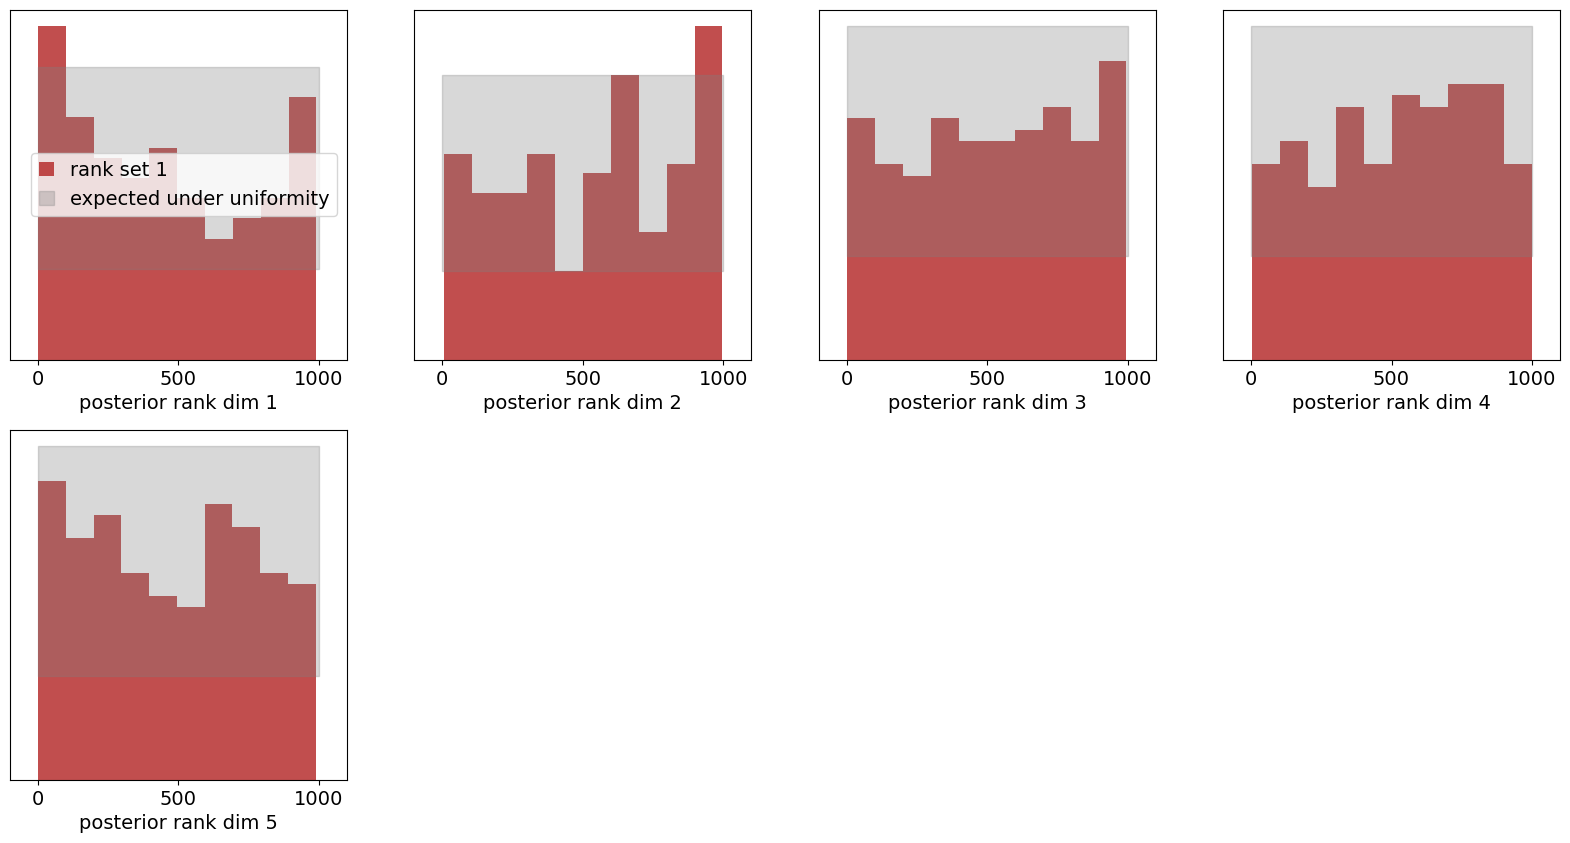

In [318]:
# fig, ax = sbc_rank_plot(
#     ranks,
#     num_posterior_samples,
#     num_bins=20,
#     figsize=(5, 3),
# )
fig, ax = sbc_rank_plot(
    ranks=ranks.cpu(),
    num_posterior_samples=num_posterior_samples,
    plot_type="hist",
    num_bins=None,  
)

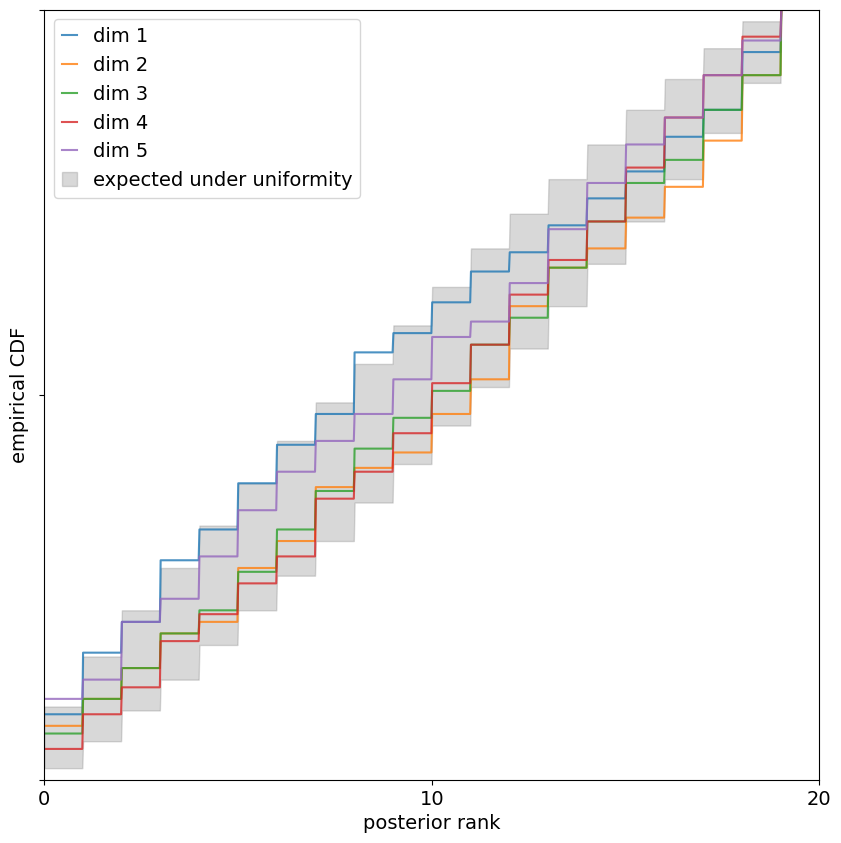

In [319]:
fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    num_bins=20,
    figsize=(10, 10),
)

### Posterior calibration with TARP

In [320]:
num_tarp_samples = 200  
thetas = prior.sample((num_tarp_samples,))
xs = get_traning_data(thetas, num_tarp_samples)
xs_standardized = (xs - x.mean(axis=0)) / (x.std(axis=0) + 1e-8)

In [321]:
xs_standardized

array([[ 1.01205341, -0.13104143,  0.1985907 , ..., -0.00422696,
        -0.73698369, -0.42557562],
       [ 1.03331705, -0.72377475, -0.65871278, ...,  1.40677785,
         0.43245553,  0.50626124],
       [-0.5732018 , -0.31787572, -1.74263361, ...,  0.7142072 ,
         0.5283938 ,  2.47850031],
       ...,
       [-0.1235371 , -0.11285925, -1.07251512, ..., -1.25099946,
        -0.58289458,  0.18223081],
       [-0.01326368, -0.34325264, -0.71299766, ..., -1.43226404,
        -0.20510427, -2.03260315],
       [ 0.92913381, -0.19017243,  1.61097956, ..., -0.46436327,
         0.0572329 , -0.73180992]])

In [322]:
from sbi.diagnostics import run_tarp
ecp, alpha = run_tarp(
    thetas,
    torch.tensor(xs_standardized, dtype=torch.float32, device=device),
    posterior,
    references=None, 
    num_posterior_samples=1000,
)

/home/leon/anaconda3/lib/python3.13/site-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 500 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 1000 samples for 200 observations:   0%|          | 0/1000 [00:00<?, ?it/s]

(<Figure size 600x600 with 1 Axes>,
 <Axes: xlabel='Credibility Level $\\alpha$', ylabel='Expected Coverage Probability'>)

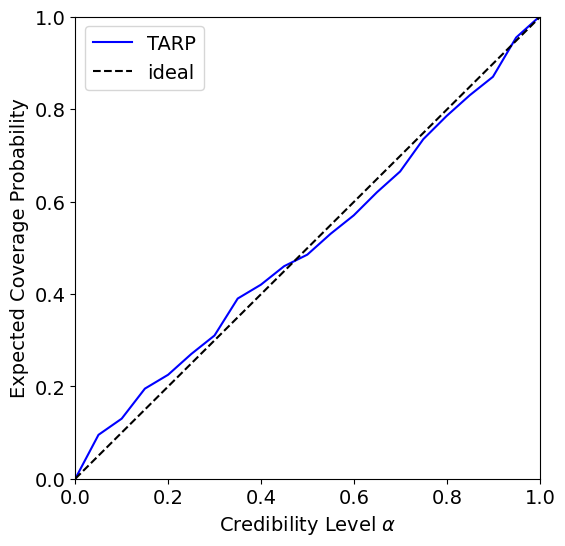

In [323]:
from sbi.analysis.plot import plot_tarp
plot_tarp(ecp.cpu(), alpha.cpu())